In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

In [2]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

data_dir = 'data\\dataflip'
val_dir = 'data\\data1'
# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
image_datasets = {
    'train': datasets.ImageFolder(os.path.join(data_dir), data_transforms['train']),
    'val': datasets.ImageFolder(os.path.join(val_dir), data_transforms['val'])
}
dataloaders = {x: DataLoader(
    image_datasets[x],
    batch_size=32,  # 增加批次大小，充分利用 GPU
    shuffle=(x=='train'),
    num_workers=6,  # 根據您的 CPU 核心數調整
    pin_memory=True,  # 加速 CPU->GPU 數據傳輸
    prefetch_factor=2,  # 每個 worker 預加載的批次數
    persistent_workers=True  # 避免每個 epoch 後重啟 workers
) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

First, let's print the model architecture to understand its structure:

Run the above code to see the structure of the model. Look for the final layer that produces the class scores, typically named something like classifier, head, or fc.

In [3]:
# Step 4: Define the Model
# Load the EfficientNet-B0 model and modify it for your number of classes.

import torchvision.models as models

# Load pretrained EfficientNet-B0 model
model = models.efficientnet_b0(pretrained=True)

# Print the model architecture
print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



From the model architecture, it looks like the final classification layer is named classifier. 

To modify this layer for your custom classification task, you should replace the classifier layer with a new Linear layer that has the appropriate number of output classes for your dataset.

In [4]:

# Modify the final layer for custom classification
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, len(class_names))

In [ ]:
# Move the model to GPU if available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)

從模型 pre_eff_45deg.pth 繼續訓練...


<All keys matched successfully>

In [6]:
import torch.optim as optim
from torch.optim import lr_scheduler

# Define loss function
criterion = torch.nn.CrossEntropyLoss()

# Define optimizer
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler
exp_lr_scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)


In [ ]:
import time
import copy
report_train_acc = []
report_val_acc = []
report_train_loss = []
report_val_loss = []
num_epochs = 50
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch}/{num_epochs - 1}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data.
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            if phase == 'train':
                report_train_acc.append(epoch_acc)
                report_train_loss.append(epoch_loss)
            else:
                report_val_acc.append(epoch_acc)
                report_val_loss.append(epoch_loss)
            # Deep copy the model
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model

# Train the model
model = train_model(model, criterion, optimizer, exp_lr_scheduler, num_epochs)

# Save the model
torch.save(model.state_dict(), 'pre_eff_45deg.pth')

Epoch 0/19
----------
train Loss: 0.4698 Acc: 0.8801
val Loss: 0.2159 Acc: 0.9350

Epoch 1/19
----------
train Loss: 0.2393 Acc: 0.9335
val Loss: 0.1240 Acc: 0.9639

Epoch 2/19
----------
train Loss: 0.1561 Acc: 0.9552
val Loss: 0.0760 Acc: 0.9778

Epoch 3/19
----------
train Loss: 0.0950 Acc: 0.9738
val Loss: 0.0526 Acc: 0.9839

Epoch 4/19
----------
train Loss: 0.0515 Acc: 0.9855
val Loss: 0.0302 Acc: 0.9924

Epoch 5/19
----------
train Loss: 0.0242 Acc: 0.9933
val Loss: 0.0130 Acc: 0.9956

Epoch 6/19
----------
train Loss: 0.0124 Acc: 0.9966
val Loss: 0.0039 Acc: 0.9986

Epoch 7/19
----------
train Loss: 0.0052 Acc: 0.9988
val Loss: 0.0006 Acc: 0.9998

Epoch 8/19
----------
train Loss: 0.0014 Acc: 0.9998
val Loss: 0.0001 Acc: 1.0000

Epoch 9/19
----------
train Loss: 0.0008 Acc: 0.9999
val Loss: 0.0000 Acc: 1.0000

Epoch 10/19
----------
train Loss: 0.0006 Acc: 0.9999
val Loss: 0.0000 Acc: 1.0000

Epoch 11/19
----------
train Loss: 0.0005 Acc: 1.0000
val Loss: 0.0000 Acc: 1.0000

Ep

RuntimeError: Caught RuntimeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torch\utils\data\_utils\worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torch\utils\data\_utils\fetch.py", line 55, in fetch
    return self.collate_fn(data)
  File "c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torch\utils\data\_utils\collate.py", line 398, in default_collate
    return collate(batch, collate_fn_map=default_collate_fn_map)
  File "c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torch\utils\data\_utils\collate.py", line 211, in collate
    return [
  File "c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torch\utils\data\_utils\collate.py", line 212, in <listcomp>
    collate(samples, collate_fn_map=collate_fn_map)
  File "c:\Users\User\anaconda3\en

# Testing

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import time
from tqdm import tqdm  # 添加進度條顯示
# 初始化模型架構
model = models.efficientnet_b0(pretrained=False)
# 修改分類器層以符合您的類別數量
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, len(class_names))

# 載入預訓練權重
model_path = "pre_eff_45deg.pth"  # 確保檔案路徑正確
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# 設置為評估模式
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# 定義測試數據轉換 
test_transform = transforms.Compose([  
    transforms.Resize((224, 224)),
    transforms.RandomRotation((0, 359)),  # 新增隨機旋轉0~359度
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    
])

# 載入測試數據集
test_dataset = datasets.ImageFolder('data\\data1', test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=4)

# 使用動態類別數量
num_classes = len(test_dataset.classes)
class_correct = [0] * num_classes
class_total = [0] * num_classes
class_predictions = [0] * num_classes
total_correct = 0
total_samples = 0


# 計算開始時間
start_time = time.time()

# 使用進度條跟踪測試進度
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="測試進度"):
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 模型預測
        outputs = model(inputs)
        _, predictions = torch.max(outputs, 1)
        
        # 統計整體正確數
        correct = (predictions == labels).sum().item()
        total_correct += correct
        total_samples += labels.size(0)
        
        # 統計每個類別的正確數和總數
        for i in range(len(labels)):
            label = labels[i].item()
            prediction = predictions[i].item()
            class_total[label] += 1
            if label == prediction:
                class_correct[label] += 1
            
            # 統計每個類別被預測的次數
            class_predictions[prediction] += 1

# 計算測試時間
test_time = time.time() - start_time

# 輸出總體準確率
overall_accuracy = 100 * total_correct / total_samples
print(f'總體準確率: {overall_accuracy:.2f}% ({total_correct}/{total_samples})')
print(f'測試完成，耗時: {test_time:.2f} 秒')

# 輸出每個類別的準確率
print("\n各類別準確率:")
for i in range(len(class_names)):
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        print(f'類別 {i}: {accuracy:.2f}% ({class_correct[i]}/{class_total[i]})')

# 輸出每個類別被預測到的次數
print("\n各類別被預測次數:")
for i in range(len(class_names)):
    print(f'類別 {i}: {class_predictions[i]}')

c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
測試進度: 100%|██████████| 157/157 [00:29<00:00,  5.29it/s]

總體準確率: 43.71% (4371/10000)
測試完成，耗時: 29.70 秒

各類別準確率:
類別 0: 0.00% (0/1)
類別 1: 0.00% (0/1)
類別 2: 0.00% (0/1)
類別 3: 0.00% (0/1)
類別 4: 0.00% (0/1)
類別 5: 0.00% (0/1)
類別 6: 100.00% (1/1)
類別 7: 100.00% (1/1)
類別 8: 100.00% (1/1)
類別 9: 0.00% (0/1)
類別 10: 0.00% (0/1)
類別 11: 100.00% (1/1)
類別 12: 0.00% (0/1)
類別 13: 0.00% (0/1)
類別 14: 0.00% (0/1)
類別 15: 0.00% (0/1)
類別 16: 100.00% (1/1)
類別 17: 0.00% (0/1)
類別 18: 0.00% (0/1)
類別 19: 0.00% (0/1)
類別 20: 100.00% (1/1)
類別 21: 100.00% (1/1)
類別 22: 100.00% (1/1)
類別 23: 0.00% (0/1)
類別 24: 100.00% (1/1)
類別 25: 0.00% (0/1)
類別 26: 0.00% (0/1)
類別 27: 0.00% (0/1)
類別 28: 100.00% (1/1)
類別 29: 0.00% (0/1)
類別 30: 100.00% (1/1)
類別 31: 0.00% (0/1)
類別 32: 0.00% (0/1)
類別 33: 0.00% (0/1)
類別 34: 100.00% (1/1)
類別 35: 100.00% (1/1)
類別 36: 0.00% (0/1)
類別 37: 0.00% (0/1)
類別 38: 100.00% (1/1)
類別 39: 100.00% (1/1)
類別 40: 0.00% (0/1)
類別 41: 100.00% (1/1)
類別 42: 0.00% (0/1)
類別 43: 0.00% (0/1)
類別 44: 100.00% (1/1)
類別 45: 100.00% (1/1)
類別 46: 100.00% (1/1)
類別 47: 100.00% (1/1)
類別 48

[0.0066 0.0779 0.3891 0.7444 0.892  0.95   0.9796 0.9919 0.9969 0.999
 0.9992 0.9993 0.9976 0.9924 0.9847 0.9746 0.9657 0.9629 0.9616 0.9661]
[7.7963e+00 4.4523e+00 2.1805e+00 8.1970e-01 3.4370e-01 1.6440e-01
 7.2700e-02 3.2800e-02 1.5800e-02 9.2000e-03 7.4000e-03 7.4000e-03
 1.1500e-02 2.8100e-02 5.1000e-02 8.3600e-02 1.1440e-01 1.2680e-01
 1.3380e-01 1.1880e-01]
[0.0362 0.2368 0.6211 0.8776 0.9361 0.9761 0.991  0.9982 1.     1.
 1.     1.     0.9999 0.9992 0.9956 0.988  0.9796 0.9852 0.9821 0.9813]
[5.3401e+00 2.8178e+00 1.2246e+00 3.7120e-01 1.9730e-01 7.3200e-02
 2.8100e-02 9.1000e-03 2.4000e-03 1.1000e-03 1.2000e-03 1.0000e-03
 1.7000e-03 4.7000e-03 1.6700e-02 4.2700e-02 6.6100e-02 4.9100e-02
 5.9700e-02 6.4800e-02]


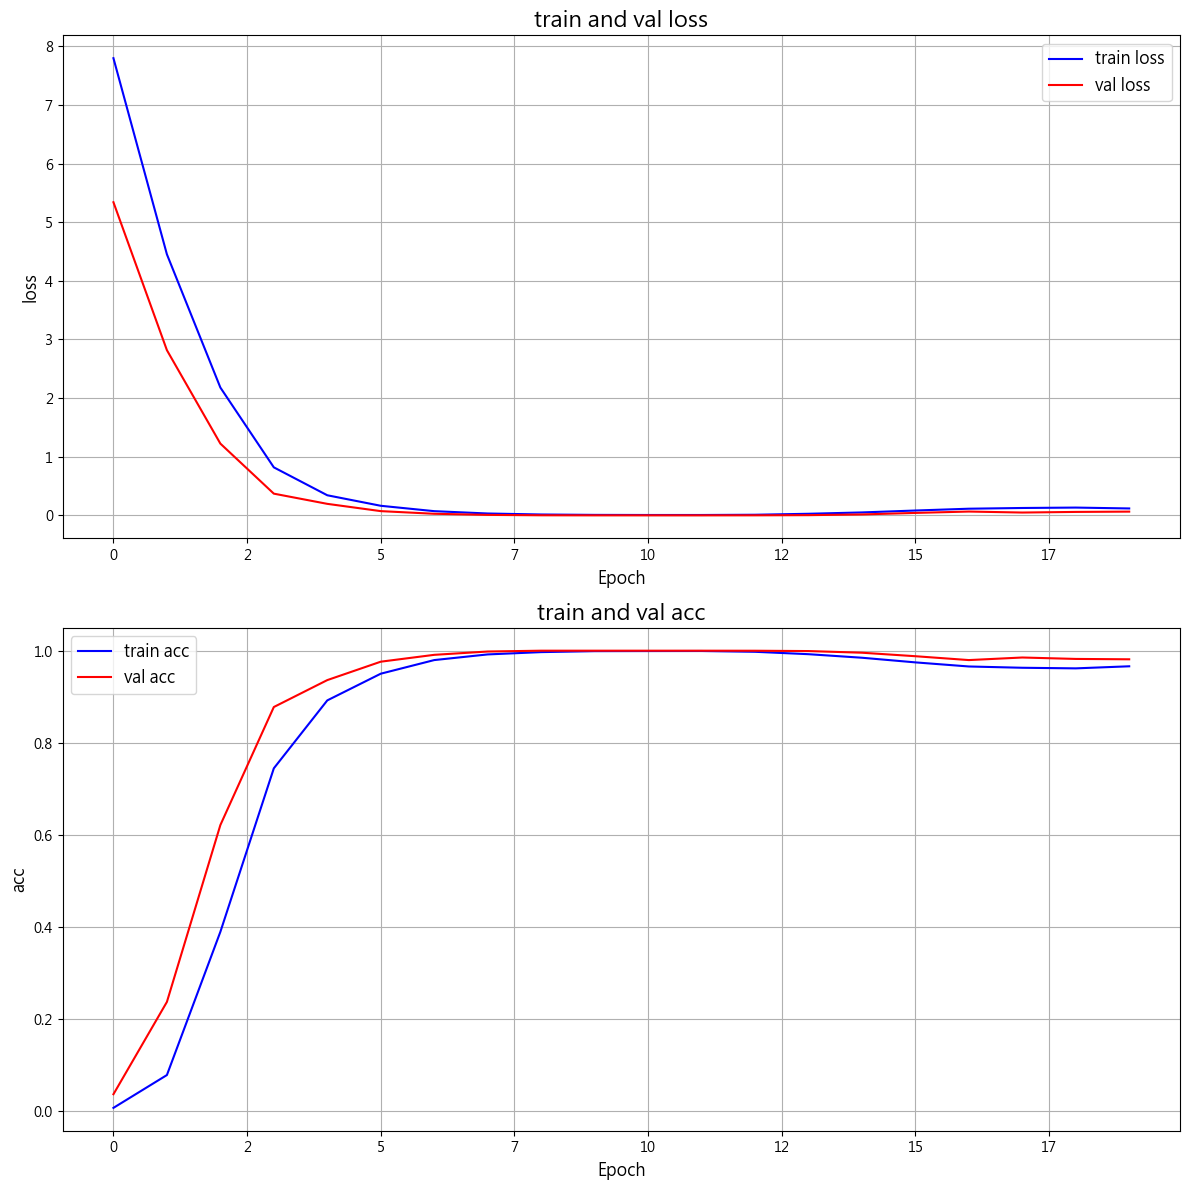

最終訓練損失: 0.1188, 最終訓練準確率: 0.9661
最終驗證損失: 0.0648, 最終驗證準確率: 0.9813


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as ticker

train_loss = report_train_loss

# 訓練準確率
train_acc = report_train_acc

val_acc = report_val_acc
# 驗證損失
val_loss = report_val_loss
# 從訓練記錄中提取數據
epochs = list(range(20))

train_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in train_acc])
train_loss = np.array([loss if isinstance(loss, float) else loss.cpu().item() for loss in train_loss])
val_acc = np.array([acc.cpu().numpy() if torch.is_tensor(acc) else acc for acc in val_acc])
val_loss = np.array([loss if isinstance(loss, float) else loss.cpu().item() for loss in val_loss])
print(train_acc)
print(train_loss)
print(val_acc)
print(val_loss)
# 設置中文字體
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei']
plt.rcParams['axes.unicode_minus'] = False

# 創建包含兩個子圖的圖表
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

# 繪製損失曲線
ax1.plot(epochs, train_loss, 'b-', label='train loss')
ax1.plot(epochs, val_loss, 'r-', label='val loss')
ax1.set_title('train and val loss', fontsize=16)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('loss', fontsize=12)
ax1.legend(fontsize=12)
ax1.grid(True)
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# 繪製準確率曲線
ax2.plot(epochs, train_acc, 'b-', label='train acc')
ax2.plot(epochs, val_acc, 'r-', label='val acc')
ax2.set_title('train and val acc', fontsize=16)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('acc', fontsize=12)
ax2.legend(fontsize=12)
ax2.grid(True)
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter('%d'))

# 顯示圖表
plt.tight_layout()
plt.show()

# 擷取關鍵統計資訊
print(f"最終訓練損失: {train_loss[-1]:.4f}, 最終訓練準確率: {train_acc[-1]:.4f}")
print(f"最終驗證損失: {val_loss[-1]:.4f}, 最終驗證準確率: {val_acc[-1]:.4f}")

c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\User\anaconda3\envs\fastervit\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


torch.return_types.max(
values=tensor([3.2638], device='cuda:0'),
indices=tensor([7], device='cuda:0'))


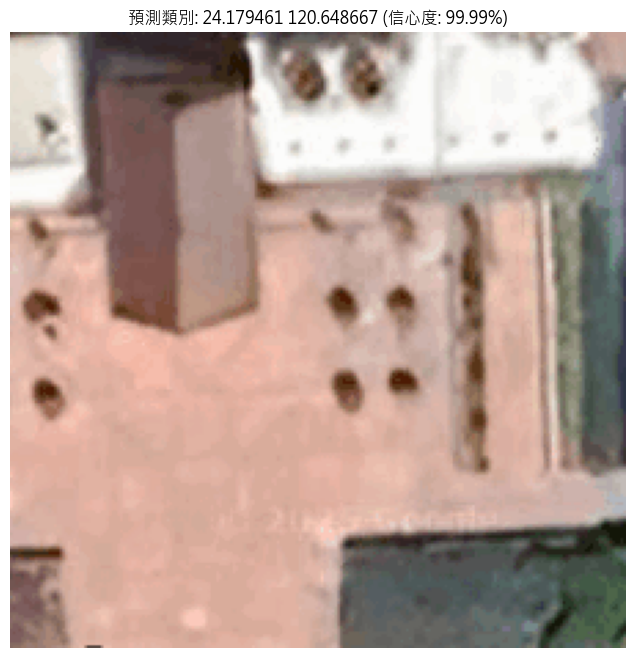


預測類別: 24.179461 120.648667
預測機率: 99.99%


In [ ]:
import torch
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt



# 初始化模型架構
model = models.efficientnet_b0(pretrained=False)
# 修改分類器層以符合您的類別數量
num_ftrs = model.classifier[1].in_features
model.classifier[1] = torch.nn.Linear(num_ftrs, len(class_names))

# 載入預訓練權重
model_path = "efficientnet_b0_custom_model.pth"  # 確保檔案路徑正確
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))

# 設置為評估模式
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# 影像預處理函數
def process_single_image(image_path):
    image = Image.open(image_path)
    # 使用與訓練時相同的轉換
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    
    # 轉換圖片
    image_tensor = transform(image)
    # 添加batch維度
    image_tensor = image_tensor.unsqueeze(0)
    return image_tensor, image

# 預測單張圖片
def predict_image(image_path):
    # 載入和處理圖片
    image_tensor, original_image = process_single_image(image_path)
    image_tensor = image_tensor.to(device)
    
    # 進行預測
    with torch.no_grad():
        outputs = model(image_tensor)
        _, predicted = torch.max(outputs, 1)
        print(torch.max(outputs, 1))
        predicted_class = predicted.item()
    
    # 計算預測機率
    probabilities = torch.nn.functional.softmax(outputs[0], dim=0)
    confidence = probabilities[predicted_class].item()
    
    # 返回結果
    return predicted_class, confidence, original_image

# 使用範例
if __name__ == "__main__":
    # 設定圖片路徑
    test_image_path = "111.png"  # 替換成您要測試的圖片
    
    # 進行預測
    predicted_class, confidence, image = predict_image(test_image_path)
    
    # 顯示結果
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(f'預測類別: {class_names[predicted_class]} (信心度: {confidence:.2%})')
    plt.axis('off')
    plt.show()
    
    print(f"\n預測類別: {class_names[predicted_class]}")
    print(f"預測機率: {confidence:.2%}")